In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
final_df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Time series/Project/final_df.csv", index_col=0)

In [ ]:
final_df

,Brent_price,world_crude_supply,global_demand_proxy
2003-01-01,30.808696,69.345818,9.638756
2003-02-01,32.662500,70.667015,8.072543
2003-03-01,30.168095,70.704776,18.073845
2003-04-01,25.035000,69.354520,29.568834
2003-05-01,25.714545,69.169601,37.680731
...,...,...,...
2025-06-01,69.846667,84.384482,-2.320013
2025-07-01,69.564783,84.820576,5.244006
2025-08-01,67.244286,85.290256,14.515912
2025-09-01,67.609091,86.427981,20.388900


Cross correlation:

Brent_price vs world_crude_supply: Max corr = -0.046 at lag 0
Brent_price vs global_demand_proxy: Max corr = 0.190 at lag -11
world_crude_supply vs global_demand_proxy: Max corr = 0.049 at lag -3


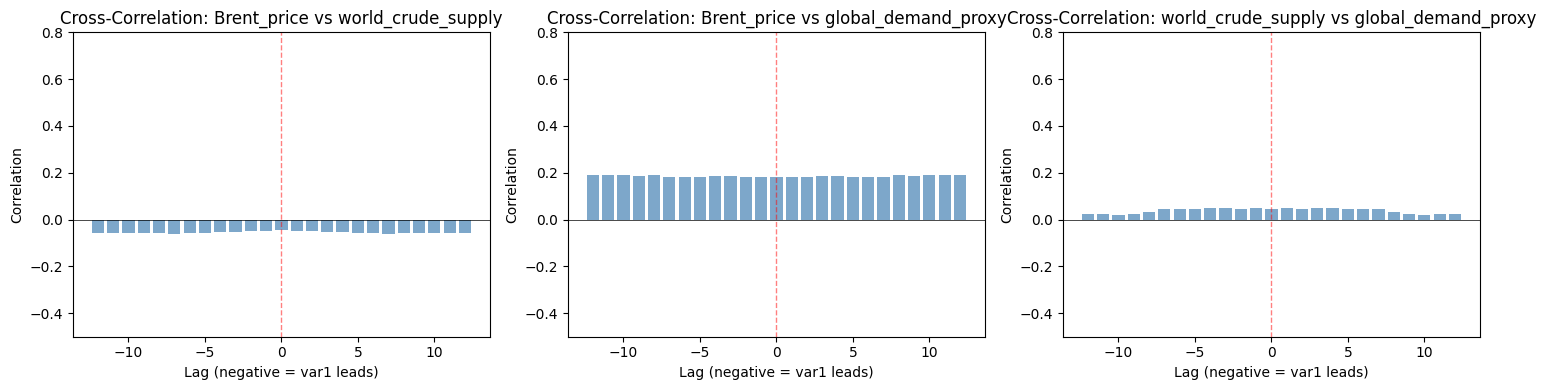

In [ ]:
# --- Cross-Correlation Analysis (Lead/Lag Relationships) ---
from scipy import stats

def cross_corr(series1, series2, max_lag=12):
    """Calculate cross-correlation at various lags"""
    correlations = []
    lags = range(-max_lag, max_lag + 1)
    for lag in lags:
        if lag < 0:
            corr = series1.iloc[:lag].corr(series2.iloc[-lag:])
        elif lag > 0:
            corr = series1.iloc[lag:].corr(series2.iloc[:-lag])
        else:
            corr = series1.corr(series2)
        correlations.append(corr)
    return lags, correlations

# Use first differences to examine lead/lag in changes
df_diff = final_df[['Brent_price', 'world_crude_supply', 'global_demand_proxy']].diff().dropna()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

pairs = [('Brent_price', 'world_crude_supply'), ('Brent_price', 'global_demand_proxy'), ('world_crude_supply', 'global_demand_proxy')]
for ax, (var1, var2) in zip(axes, pairs):
    lags, corrs = cross_corr(df_diff[var1], df_diff[var2], max_lag=12)
    ax.bar(lags, corrs, color='steelblue', alpha=0.7)
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    ax.axvline(x=0, color='red', linestyle='--', linewidth=1, alpha=0.5)
    ax.set_xlabel('Lag (negative = var1 leads)')
    ax.set_ylabel('Correlation')
    ax.set_title(f'Cross-Correlation: {var1} vs {var2}')
    ax.set_ylim(-0.5, 0.8)

    # Find max correlation and its lag
    max_idx = np.argmax(corrs)
    print(f"{var1} vs {var2}: Max corr = {corrs[max_idx]:.3f} at lag {lags[max_idx]}")

plt.tight_layout()
plt.show()

In [ ]:
df_diff

,Brent_price,world_crude_supply,global_demand_proxy
2003-02-01,1.853804,1.321197,-1.566213
2003-03-01,-2.494405,0.037761,10.001302
2003-04-01,-5.133095,-1.350256,11.494989
2003-05-01,0.679545,-0.184919,8.111897
2003-06-01,1.852121,-0.185788,-4.293188
...,...,...,...
2025-06-01,5.753939,1.094814,22.700814
2025-07-01,-0.281884,0.436094,7.564019
2025-08-01,-2.320497,0.469680,9.271906
2025-09-01,0.364805,1.137725,5.872988


In [ ]:
from statsmodels.tsa.api import VAR

# Use final stationary dataframe
model = VAR(df_diff)

# Allow up to 12 lags (monthly data)
lag_selection = model.select_order(maxlags=12)

# Print summary table
print(lag_selection.summary())

# Extract optimal lag based on BIC
optimal_lag = lag_selection.selected_orders['aic']
print("Optimal lag selected by AIC:", optimal_lag)

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0        9.772       9.813   1.754e+04       9.789
1        9.606      9.770*   1.486e+04      9.672*
2        9.587       9.873   1.457e+04       9.702
3        9.603       10.01   1.482e+04       9.768
4       9.569*       10.10  1.432e+04*       9.783
5        9.618       10.27   1.505e+04       9.882
6        9.615       10.39   1.500e+04       9.928
7        9.629       10.53   1.522e+04       9.991
8        9.615       10.64   1.502e+04       10.03
9        9.634       10.78   1.531e+04       10.10
10       9.647       10.92   1.553e+04       10.16
11       9.682       11.07   1.610e+04       10.24
12       9.723       11.24   1.679e+04       10.33
--------------------------------------------------
Optimal lag selected by AIC: 4


Optimal Lag selected BIC = 1, AIC = 4

The results of the lag selection procedure indicate that the AIC and FPE are minimized at lag 4, suggesting that a four-period lag structure provides the best balance between model fit and parsimony. In contrast, the BIC and HQIC select a shorter lag length of one period, reflecting their stronger penalty for model complexity. Since the AIC is generally preferred in VAR models for capturing richer dynamics in macroeconomic time series, a lag length of four months was chosen for the final model.

Selecting four lags allows the model to capture delayed interactions between oil prices, global supply, and global demand conditions. In the context of oil markets, this lag structure is economically reasonable because adjustments in production and responses to demand shocks often occur gradually over several months rather than instantaneously.

In [ ]:
from statsmodels.tsa.stattools import grangercausalitytests

# df_final should be your stationary dataframe with columns: ['PCE','AHE','PCEPI']
# optimal_lag should come from your 2C lag selection (e.g., BIC)
GC_LAG = int(optimal_lag)  # keep one lag value consistent everywhere
ALPHA = 0.05

def run_granger_and_explain(df: pd.DataFrame, cause: str, effect: str, maxlag: int, alpha: float = 0.05):
    """
    Runs Granger causality test: H0 = cause does NOT Granger-cause effect.
    Returns a dict with F-test statistic + p-value and a plain-English interpretation.
    """
    # statsmodels expects data ordered as [effect, cause]
    data = df[[effect, cause]].dropna()

    # Run test (no verbose printing)
    res = grangercausalitytests(data, maxlag=maxlag, verbose=False)

    # Use the F-test from the chosen lag
    ftest = res[maxlag][0]["ssr_ftest"]
    f_stat, p_val, df_denom, df_num = ftest[0], ftest[1], ftest[2], ftest[3]

    decision = "REJECT" if p_val < alpha else "FAIL TO REJECT"

    # Plain-English explanation
    if decision == "REJECT":
        explanation = (
            f"Past values of {cause} add statistically significant predictive power for {effect} "
            f"beyond past {effect} alone (evidence of Granger-causality at α={alpha})."
        )
    else:
        explanation = (
            f"We do not find evidence that past {cause} improves prediction of {effect} "
            f"once past {effect} is included (no Granger-causality at α={alpha})."
        )

    return {
        "Direction (H0)": f"{cause} ↛ {effect}",
        "Lag used": maxlag,
        "F-stat": float(f_stat),
        "p-value": float(p_val),
        "Decision @ α=0.05": decision,
        "Interpretation": explanation
    }

# --- Hypothesized directions---
tests_to_run = [
    ("world_crude_supply", "Brent_price"),    # world_crude_supply → Brent_price
    ("global_demand_proxy", "Brent_price"),  # PCEPI → Brent_price
]

results = []
for cause, effect in tests_to_run:
    results.append(run_granger_and_explain(df_diff, cause, effect, maxlag=GC_LAG, alpha=ALPHA))

results_df = pd.DataFrame(results)

# Display results table
display(results_df)

# Optional: print a clean narrative summary (good for the write-up section)
for row in results:
    print(f"\nGranger causality F-test (lag={row['Lag used']}): H0: {row['Direction (H0)']}")
    print(f"F = {row['F-stat']:.4f}, p = {row['p-value']:.4f} → {row['Decision @ α=0.05']}")
    print(f"Explanation: {row['Interpretation']}")

,Direction (H0),Lag used,F-stat,p-value,Decision @ α=0.05,Interpretation
0,world_crude_supply ↛ Brent_price,4,0.293108,0.882314,FAIL TO REJECT,We do not find evidence that past world_crude_...
1,global_demand_proxy ↛ Brent_price,4,1.668381,0.157714,FAIL TO REJECT,We do not find evidence that past global_deman...



Granger causality F-test (lag=4): H0: world_crude_supply ↛ Brent_price
F = 0.2931, p = 0.8823 → FAIL TO REJECT
Explanation: We do not find evidence that past world_crude_supply improves prediction of Brent_price once past Brent_price is included (no Granger-causality at α=0.05).

Granger causality F-test (lag=4): H0: global_demand_proxy ↛ Brent_price
F = 1.6684, p = 0.1577 → FAIL TO REJECT
Explanation: We do not find evidence that past global_demand_proxy improves prediction of Brent_price once past Brent_price is included (no Granger-causality at α=0.05).


The results show that neither world crude oil supply nor the global demand proxy Granger-cause Brent oil prices at the 5% significance level.

For the relationship between world crude oil supply and Brent prices, the test produced an F-statistic of 0.293 with a p-value of 0.882. Since the p-value is much larger than the significance level of 0.05, the null hypothesis cannot be rejected. This suggests that past changes in global crude oil supply do not provide statistically significant predictive information for Brent oil prices in this model.

Similarly, the test examining whether global demand (Kilian index) Granger-causes Brent prices yielded an F-statistic of 1.668 with a p-value of 0.158. Again, the null hypothesis cannot be rejected at the 5% level. Therefore, the results do not provide statistical evidence that past global demand conditions help predict Brent oil price movements within the chosen lag structure.

In [ ]:
# Train test split: last 12 months
train = df_diff[:-24]
test = df_diff[-24:]

print("Train size:", len(train))
print("Test size:", len(test))

Train size: 249
Test size: 24


In [ ]:
# Fit VAR on training data only
model = VAR(train)

max_lags = 12
lag_results = model.select_order(maxlags=max_lags)

print(lag_results.summary())

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0        9.893       9.937   1.978e+04       9.910
1        9.714      9.889*   1.654e+04      9.785*
2        9.695       10.00   1.624e+04       9.819
3        9.705       10.14   1.640e+04       9.882
4       9.676*       10.25  1.593e+04*       9.906
5        9.727       10.43   1.677e+04       10.01
6        9.726       10.56   1.677e+04       10.06
7        9.747       10.71   1.713e+04       10.14
8        9.737       10.83   1.697e+04       10.18
9        9.758       10.99   1.734e+04       10.25
10       9.774       11.13   1.764e+04       10.32
11       9.814       11.31   1.839e+04       10.42
12       9.850       11.47   1.910e+04       10.50
--------------------------------------------------


Optimal lag for BIC is lag 4

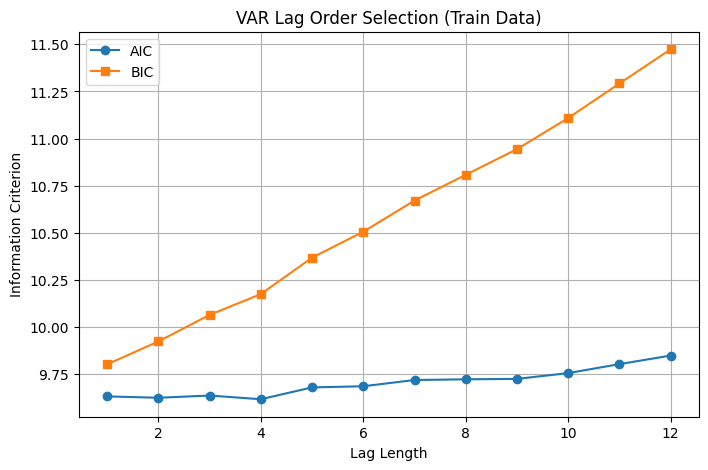

Optimal lag selected by aic (train data): 4


In [ ]:
aic_values = []
bic_values = []

for i in range(1, max_lags + 1):
    result = model.fit(i)
    aic_values.append(result.aic)
    bic_values.append(result.bic)

# Plot
plt.figure(figsize=(8,5))
plt.plot(range(1, max_lags + 1), aic_values, marker='o', label='AIC')
plt.plot(range(1, max_lags + 1), bic_values, marker='s', label='BIC')
plt.xlabel('Lag Length')
plt.ylabel('Information Criterion')
plt.title('VAR Lag Order Selection (Train Data)')
plt.legend()
plt.grid(True)
plt.show()

# Choose lag via BIC
optimal_lag = lag_results.selected_orders['aic']
print(f"Optimal lag selected by aic (train data): {optimal_lag}")

Fit VAR model using lag 4:

In [ ]:
# ---- 1. Fit VAR using chosen lag (from 3A) ----

var_model = VAR(train)
var_results = var_model.fit(optimal_lag)

# Print full regression summary
print(var_results.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Mon, 09, Mar, 2026
Time:                     04:35:24
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                    10.1755
Nobs:                     245.000    HQIC:                   9.84260
Log likelihood:          -2182.14    FPE:                    15039.8
AIC:                      9.61816    Det(Omega_mle):         12879.0
--------------------------------------------------------------------
Results for equation Brent_price
                            coefficient       std. error           t-stat            prob
-----------------------------------------------------------------------------------------
const                          0.167319         0.369725            0.453           0.651
L1.Brent_price                 0.362148         0.066567            5.440           0.000
L1.world_crude_sup

**Brent Price Equation**

The Brent price equation examines how past values of oil prices, supply, and demand influence current oil prices. The most notable result is that the first lag of Brent price is highly significant, with a coefficient of 0.36 (p < 0.001). This indicates strong short-run persistence in oil prices, meaning that current price movements are strongly influenced by prices in the previous period.

Among the external variables, the first lag of the global demand proxy is statistically significant (p = 0.03), suggesting that higher global economic activity in the previous period is associated with increases in Brent oil prices. This finding is consistent with economic theory, as stronger global economic activity increases demand for energy and tends to push oil prices upward.

In contrast, none of the lagged values of world crude oil supply are statistically significant in the Brent price equation. This suggests that short-term oil price movements are not strongly driven by past supply changes in this model.

**World Crude Oil Supply Equation**

The supply equation analyzes how production responds to past values of oil prices, supply, and demand. Most coefficients in this equation are statistically insignificant, indicating that global crude oil production does not respond strongly to short-run fluctuations in the other variables.

However, the fourth lag of the global demand proxy is statistically significant (p = 0.001). This suggests that stronger global economic activity may lead to increased oil production after several months, reflecting the delayed adjustment of supply to changes in market conditions. This delayed response is consistent with the oil industry, where production changes often require time due to operational and investment constraints.

**Global Demand Proxy Equation**

The demand equation shows several statistically significant relationships. The first and second lags of Brent price are significant, indicating that oil price movements influence global economic activity indicators. This may reflect the broader macroeconomic effects of energy price fluctuations.

Additionally, the first lag of world crude oil supply is significant and negative, suggesting that increases in supply may be associated with lower global demand indicators in the following period. This relationship may capture the interaction between supply conditions and global economic cycles.

The demand proxy also exhibits strong persistence, as both the first and fourth lags of the demand index are statistically significant. This indicates that global economic activity tends to evolve gradually over time rather than changing abruptly.

The correlation matrix of residuals shows relatively low correlations between the error terms of the three equations. This suggests that the VAR model captures most of the systematic relationships among the variables, leaving only weak contemporaneous correlations in the residuals.

In [ ]:
# ---- Stability Check ----

roots = var_results.roots

print("Roots:")
print(roots)

print("Absolute values of roots:")
print(np.abs(roots))

print("Is VAR stable?", np.all(np.abs(roots) > 1))

Roots:
[ 1.71773998-4.37305424j  1.71773998+4.37305424j -3.06011964-0.j
 -1.78615546-0.j          1.45183369-0.90087826j  1.45183369+0.90087826j
  0.12446684-1.63406564j  0.12446684+1.63406564j  1.15283367+1.10605078j
  1.15283367-1.10605078j -0.85714991+1.23271209j -0.85714991-1.23271209j]
Absolute values of roots:
[4.69832246 4.69832246 3.06011964 1.78615546 1.70862596 1.70862596
 1.6387991  1.6387991  1.59761504 1.59761504 1.50142767 1.50142767]
Is VAR stable? True


In [ ]:
print(var_results.is_stable())

True


This result confirms that the estimated VAR model is stable and dynamically consistent, meaning that shocks to the system will gradually dissipate over time rather than causing explosive behavior. In practical terms, this implies that the relationships between Brent oil prices, global crude oil supply, and the global demand proxy evolve in a predictable and mean-reverting manner within the model.

In [ ]:
# Portmanteau (whiteness) test
whiteness_test = var_results.test_whiteness(nlags=12)

print(whiteness_test.summary())

Portmanteau-test for residual autocorrelation. H_0: residual autocorrelation up to lag 12 is zero. Conclusion: fail to reject H_0 at 5% significance level.
Test statistic Critical value p-value df
----------------------------------------
         83.22          92.81   0.172 72
----------------------------------------


The test produced a test statistic of 83.22, which is below the critical value of 92.81, with a p-value of 0.172. Since the p-value is greater than the 5% significance level, we fail to reject the null hypothesis.

This result indicates that there is no statistically significant evidence of residual autocorrelation in the model up to lag 12. In other words, the VAR model has effectively captured the serial dependence in the data, and the residuals behave approximately like white noise.

In [ ]:
from statsmodels.stats.diagnostic import acorr_ljungbox

residuals = var_results.resid

for col in residuals.columns:
    print(f"\nLjung-Box test for {col}:")
    lb_test = acorr_ljungbox(residuals[col], lags=[12], return_df=True)
    print(lb_test)


Ljung-Box test for Brent_price:
     lb_stat  lb_pvalue
12  8.585344    0.73788

Ljung-Box test for world_crude_supply:
      lb_stat  lb_pvalue
12  13.458955   0.336582

Ljung-Box test for global_demand_proxy:
      lb_stat  lb_pvalue
12  13.765097    0.31596


To further evaluate the adequacy of the VAR model, Ljung–Box tests were conducted on the residuals of each equation. The Ljung–Box test examines whether residuals are independently distributed by testing the null hypothesis that there is no autocorrelation up to a specified lag (lag 12).

For the Brent price equation, the Ljung–Box test produced a statistic of 8.59 with a p-value of 0.738. Since the p-value is much greater than the 5% significance level, we fail to reject the null hypothesis, indicating that there is no evidence of autocorrelation in the residuals of the Brent price equation.

For the world crude oil supply equation, the test statistic is 13.46 with a p-value of 0.337. Again, the p-value exceeds 0.05, meaning that the null hypothesis of no residual autocorrelation cannot be rejected.

Similarly, for the global demand proxy equation, the Ljung–Box statistic is 13.77 with a p-value of 0.316, which also indicates no statistically significant residual autocorrelation.

Overall, the Ljung–Box results suggest that the residuals from all three VAR equations behave approximately like white noise. This implies that the model has adequately captured the time-series dynamics of Brent oil prices, global crude oil supply, and global demand conditions. The absence of residual autocorrelation supports the validity of the VAR specification and indicates that the chosen lag structure effectively accounts for the serial dependence present in the data.

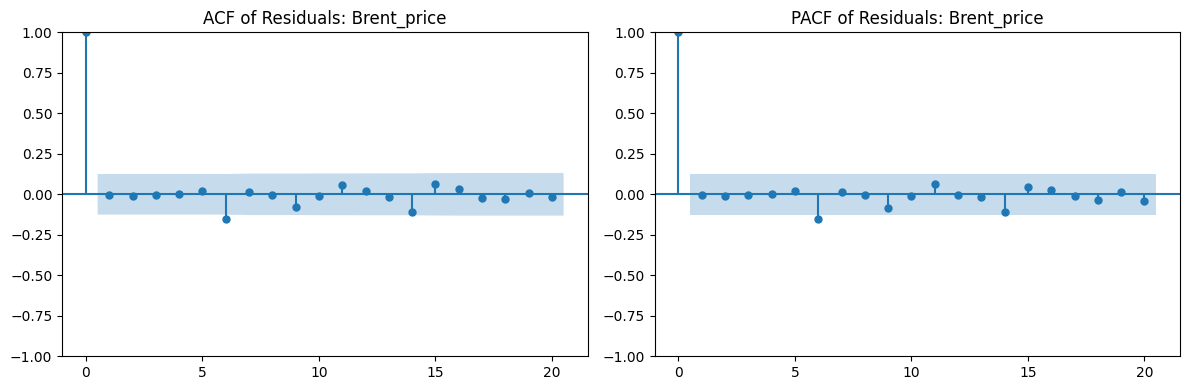

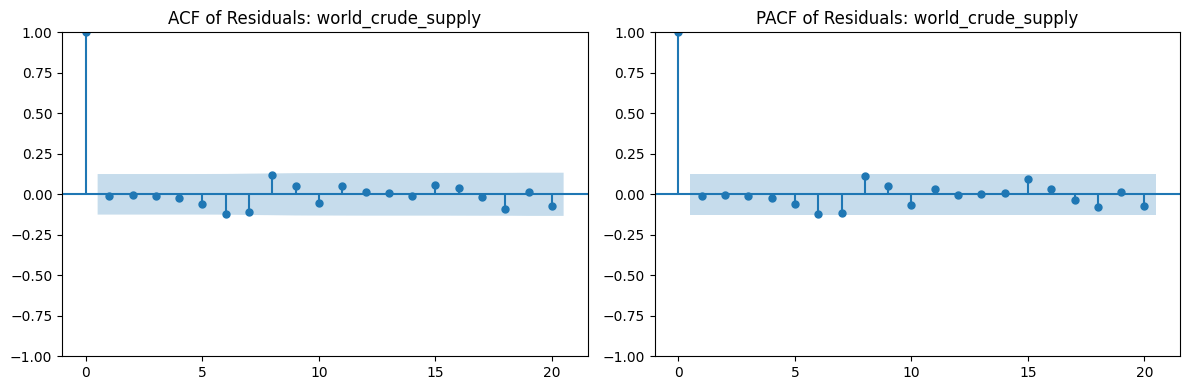

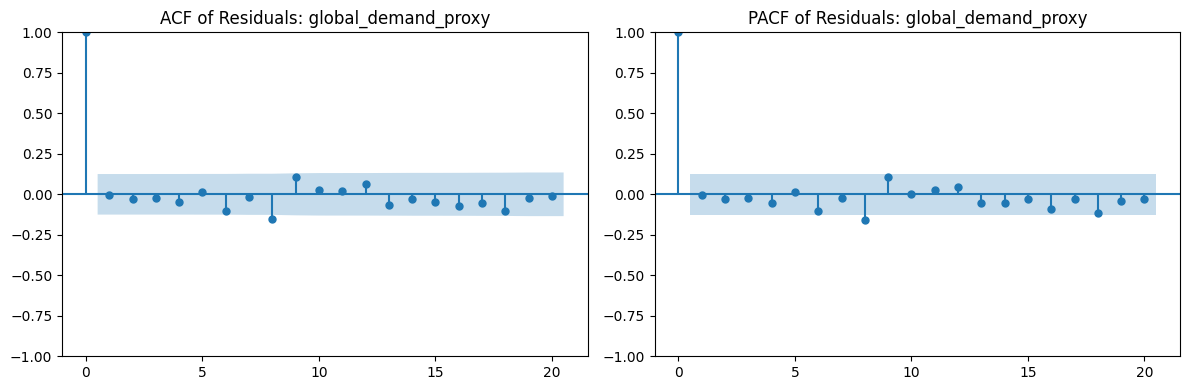

In [ ]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

residuals = var_results.resid

for col in residuals.columns:
    fig, axes = plt.subplots(1, 2, figsize=(12,4))

    plot_acf(residuals[col], lags=20, ax=axes[0])
    axes[0].set_title(f"ACF of Residuals: {col}")

    plot_pacf(residuals[col], lags=20, ax=axes[1], method='ywm')
    axes[1].set_title(f"PACF of Residuals: {col}")

    plt.tight_layout()
    plt.show()

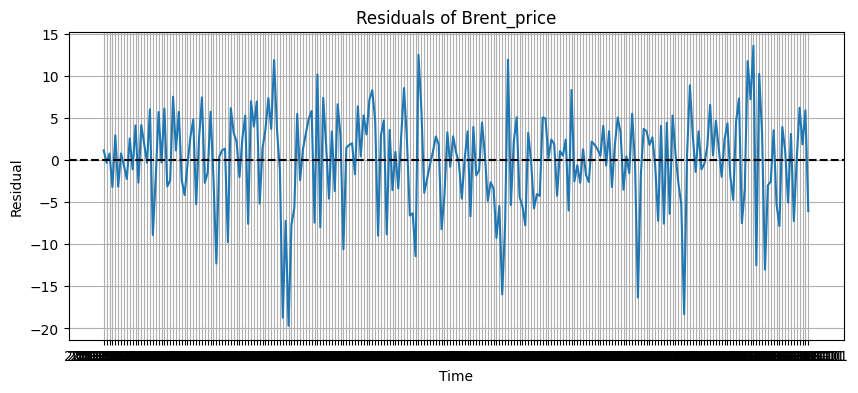

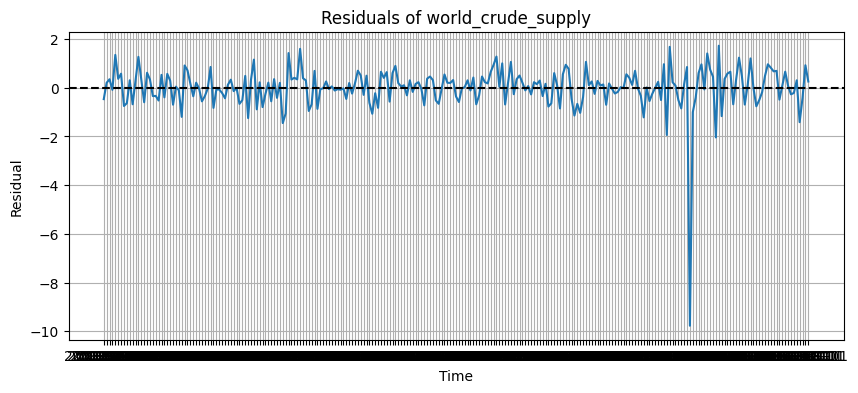

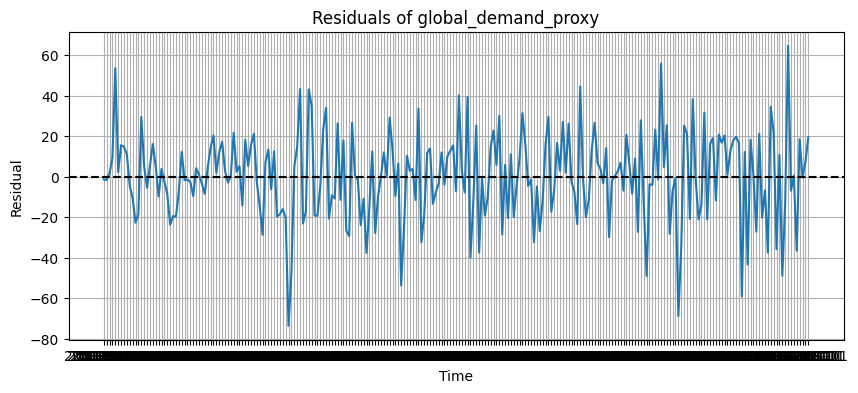

In [ ]:
for col in residuals.columns:
    plt.figure(figsize=(10,4))
    plt.plot(residuals.index, residuals[col])
    plt.axhline(0, color='black', linestyle='--')
    plt.title(f"Residuals of {col}")
    plt.xlabel("Time")
    plt.ylabel("Residual")
    plt.grid(True)
    plt.show()

**Forecast:**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

n_forecast = len(test)

lag_order = var_results.k_ar
forecast_input = train.values[-lag_order:]

forecast_diff = var_results.forecast(
    y=forecast_input,
    steps=n_forecast
)

forecast_diff_df = pd.DataFrame(
    forecast_diff,
    index=test.index,
    columns=train.columns
)

In [ ]:
# last observed level before forecast starts
last_obs = final_df.loc[train.index[-1]]

forecast_levels = forecast_diff_df.cumsum() + last_obs

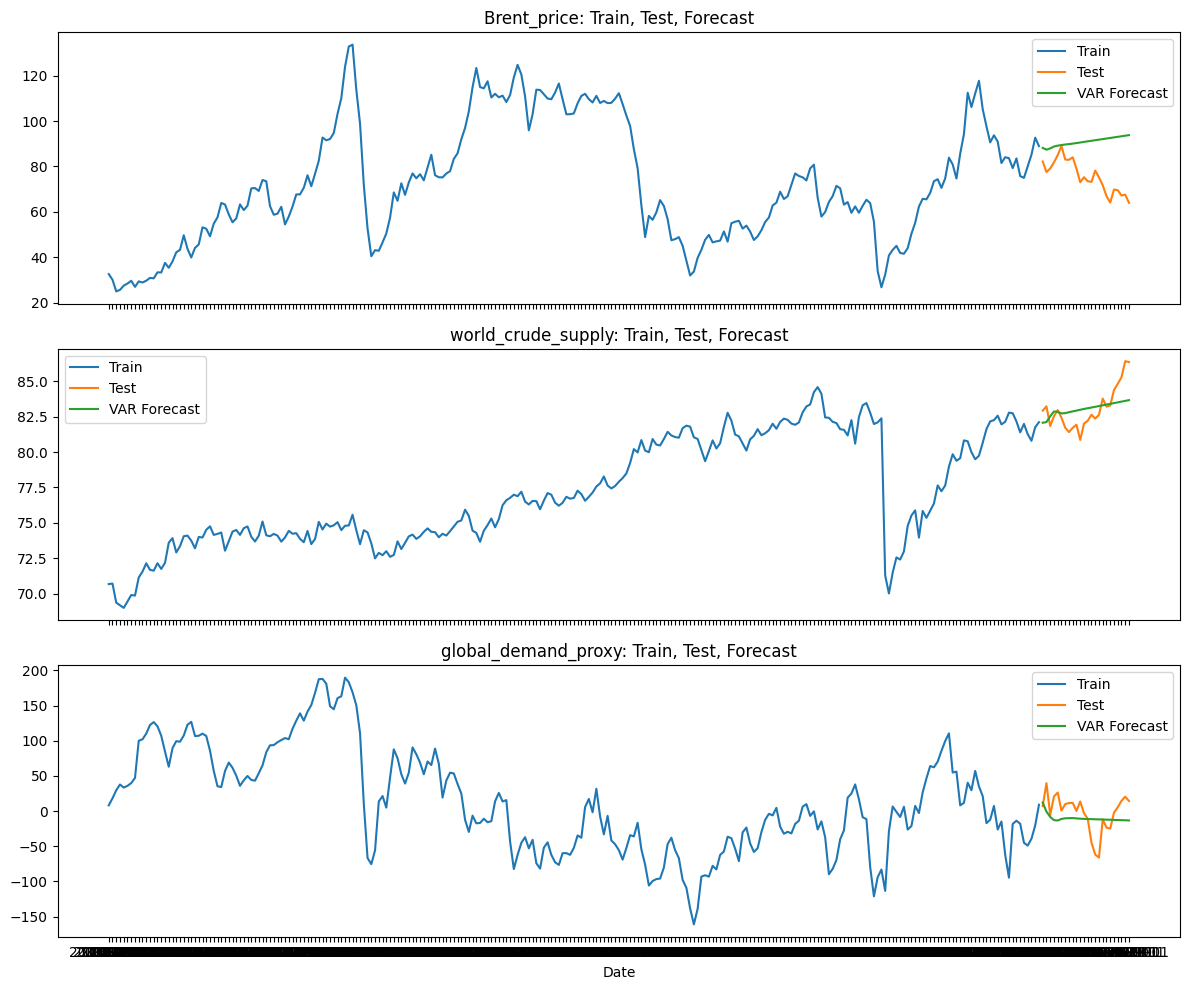

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

variables = ["Brent_price", "world_crude_supply", "global_demand_proxy"]

for i, var in enumerate(variables):

    axes[i].plot(final_df.loc[train.index, var], label="Train")
    axes[i].plot(final_df.loc[test.index, var], label="Test")
    axes[i].plot(forecast_levels[var], label="VAR Forecast")

    axes[i].set_title(f"{var}: Train, Test, Forecast")
    axes[i].legend()

axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()

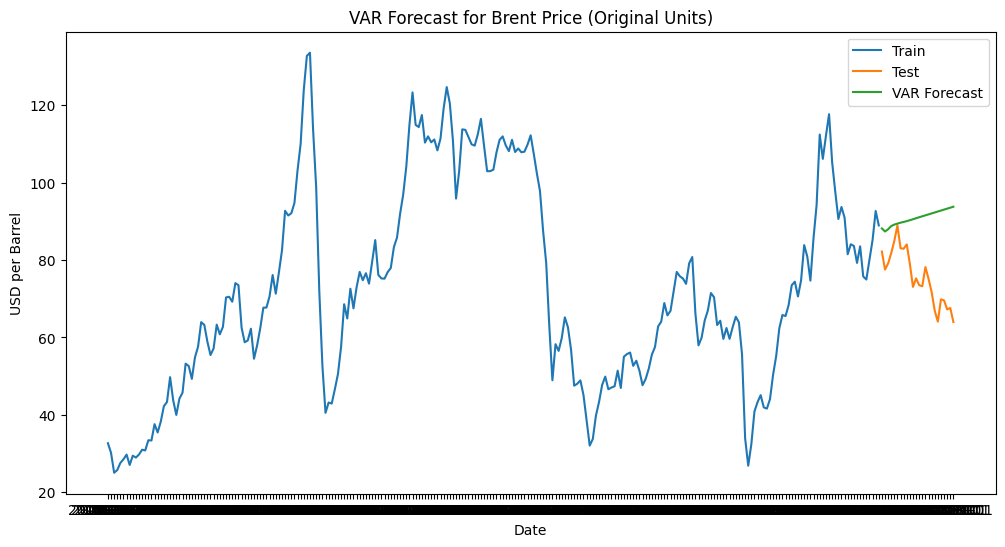

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(final_df.loc[train.index, "Brent_price"], label="Train")
plt.plot(final_df.loc[test.index, "Brent_price"], label="Test")
plt.plot(forecast_levels["Brent_price"], label="VAR Forecast")

plt.title("VAR Forecast for Brent Price (Original Units)")
plt.xlabel("Date")
plt.ylabel("USD per Barrel")
plt.legend()

plt.show()

In [ ]:
import numpy as np
import pandas as pd

brent_results = pd.DataFrame({
    "Date": test.index,
    "Actual_Brent": final_df.loc[test.index, "Brent_price"],
    "Forecast_Brent": forecast_levels.loc[test.index, "Brent_price"]
})

brent_results = brent_results.set_index("Date")

brent_results.head()

,Actual_Brent,Forecast_Brent
Date,,
2023-11-01,82.186364,88.166586
2023-12-01,77.540952,87.384469
2024-01-01,79.110000,87.953917
2024-02-01,81.795714,88.786908
2024-03-01,84.961429,89.165762


In [ ]:
#brent_results.to_csv("/content/drive/MyDrive/Colab Notebooks/Time series/Project/var_forecast.csv")

**Error metrics:**

In [ ]:
y_true = brent_results["Actual_Brent"].values
y_pred = brent_results["Forecast_Brent"].values

In [ ]:
mae = np.mean(np.abs(y_true - y_pred))

mse = np.mean((y_true - y_pred) ** 2)

mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

smape = 100 * np.mean(
    2 * np.abs(y_pred - y_true) /
    (np.abs(y_true) + np.abs(y_pred))
)


seasonal_lag = 12
# seasonal naive forecast errors using training data
naive_errors = (
    final_df.loc[train.index, "Brent_price"]
    - final_df.loc[train.index, "Brent_price"].shift(seasonal_lag)
).dropna()
mae_naive = np.mean(np.abs(naive_errors))
mase = mae / mae_naive

print("VAR Forecast Metrics (Brent Price)")
print("----------------------------------")
print(f"MAE:   {mae:.4f}")
print(f"MSE:   {mse:.4f}")
print(f"MAPE:  {mape:.4f}%")
print(f"sMAPE: {smape:.4f}%")
print(f"MASE:  {mase:.4f}")

VAR Forecast Metrics (Brent Price)
----------------------------------
MAE:   15.3374
MSE:   306.3047
MAPE:  21.5034%
sMAPE: 18.7710%
MASE:  0.7579


Overall, these results suggest that the VAR model does not provide strong forecasting performance for Brent crude oil prices over the evaluation period. While the VAR framework captures the dynamic interactions between oil prices, supply, and global demand, these relationships appear insufficient for generating accurate short-term forecasts in this dataset. This outcome highlights the difficulty of predicting oil prices, which are often influenced by unpredictable geopolitical events, market expectations, and other external shocks not captured by the model.

**Cointegration test:**

In [ ]:
from statsmodels.tsa.vector_ar.vecm import coint_johansen

In [ ]:
data_levels = final_df[[
    "Brent_price",
    "world_crude_supply",
    "global_demand_proxy"
]]

In [ ]:
johansen_test = coint_johansen(
    data_levels,
    det_order=0,   # deterministic trend assumption
    k_ar_diff=4    # number of lagged differences (same as VAR lag - 1)
)

In [ ]:
print("Trace statistics:")
print(johansen_test.lr1)

Trace statistics:
[31.89650285 10.60443727  3.42178309]


In [ ]:
for i in range(len(johansen_test.lr1)):
    print(f"H0: r ≤ {i}")
    print("Trace statistic:", johansen_test.lr1[i])
    print("95% critical value:", johansen_test.cvt[i,1])
    print()

H0: r ≤ 0
Trace statistic: 31.89650285096146
95% critical value: 29.7961

H0: r ≤ 1
Trace statistic: 10.604437267318776
95% critical value: 15.4943

H0: r ≤ 2
Trace statistic: 3.4217830940250167
95% critical value: 3.8415



Interpretation:

Test 1: r = 0 (no cointegration)
- 31.90 > 29.68
- Reject the null hypothesis.
- This means there is at least one cointegrating relationship.

Test 2: r ≤ 1
- 10.60 < 15.41
- Fail to reject the null.
- This means there is at most one cointegrating relationship.

Final conclusion:

The Johansen test indicates one cointegrating relationship (r = 1) among:
- Brent price
- World crude oil supply
- Global demand proxy

This suggests that while the individual series may be non-stationary, they share a long-run equilibrium relationship.

The Johansen cointegration test indicates the presence of one cointegrating relationship among Brent oil prices, global crude oil supply, and global demand conditions. This finding suggests that these variables share a long-run equilibrium relationship, consistent with economic theory in which oil prices adjust to balance global supply and demand conditions over time.

**VECM model**

In [ ]:
from statsmodels.tsa.vector_ar.vecm import VECM
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Split level data into train/test using your existing indices
vecm_train = final_df.loc[train.index, [
    "Brent_price", "world_crude_supply", "global_demand_proxy"
]].dropna()

vecm_test = final_df.loc[test.index, [
    "Brent_price", "world_crude_supply", "global_demand_proxy"
]].dropna()

# Scale using TRAIN only
scaler = StandardScaler()
vecm_train_scaled = pd.DataFrame(
    scaler.fit_transform(vecm_train),
    index=vecm_train.index,
    columns=vecm_train.columns
)

# Fit VECM on scaled training data
vecm_model = VECM(
    vecm_train_scaled,
    k_ar_diff=4,
    coint_rank=1,
    deterministic="co"
)

vecm_results = vecm_model.fit()

# Forecast test horizon
vecm_forecast_scaled = vecm_results.predict(steps=len(vecm_test))

vecm_forecast_scaled_df = pd.DataFrame(
    vecm_forecast_scaled,
    index=vecm_test.index,
    columns=vecm_train.columns
)

# Back to original units
vecm_forecast_df = pd.DataFrame(
    scaler.inverse_transform(vecm_forecast_scaled_df),
    index=vecm_forecast_scaled_df.index,
    columns=vecm_forecast_scaled_df.columns
)

In [ ]:
print(vecm_results.summary())

Det. terms outside the coint. relation & lagged endog. parameters for equation Brent_price
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      0.0056      0.014      0.411      0.681      -0.021       0.032
L1.Brent_price             0.3678      0.065      5.692      0.000       0.241       0.494
L1.world_crude_supply     -0.0092      0.058     -0.159      0.873      -0.123       0.104
L1.global_demand_proxy     0.1051      0.046      2.309      0.021       0.016       0.194
L2.Brent_price             0.0061      0.069      0.088      0.930      -0.130       0.142
L2.world_crude_supply      0.0825      0.058      1.429      0.153      -0.031       0.196
L2.global_demand_proxy    -0.0517      0.046     -1.123      0.262      -0.142       0.039
L3.Brent_price            -0.0692      0.071     -0.974      0.330      -0.208       0.070

**VECM Results: Brent Price Equation**

The Vector Error Correction Model (VECM) was estimated to capture both the short-run dynamics and the long-run equilibrium relationship among Brent crude oil prices, global crude oil supply, and global demand conditions. The Brent price equation explains how short-run changes in Brent prices respond to lagged values of the variables in the system.

The results indicate strong persistence in oil prices. The first lag of Brent price is highly statistically significant with a coefficient of 0.368 (p < 0.001). This suggests that Brent price movements exhibit momentum, where current price changes are strongly influenced by price movements in the previous period. Such persistence is common in commodity markets where price adjustments occur gradually.

The first lag of the global demand proxy is also statistically significant (p = 0.021) with a positive coefficient of 0.105. This indicates that increases in global economic activity tend to lead to higher Brent oil prices in the following period. This result is consistent with economic theory: stronger global demand increases energy consumption, which pushes oil prices upward.

In contrast, the lagged values of world crude oil supply are not statistically significant in the Brent price equation. This suggests that short-run fluctuations in global oil production do not immediately affect Brent prices within the model. This result may reflect the fact that oil supply adjustments typically occur slowly due to production constraints, investment cycles, and strategic production decisions by major oil-producing countries.

Most higher-order lags of Brent prices, supply, and demand are not statistically significant, indicating that the strongest short-run effects occur primarily within the first lag. Overall, the results suggest that Brent oil prices are primarily influenced by their own past values and by changes in global demand conditions, while supply responses tend to operate over longer horizons.

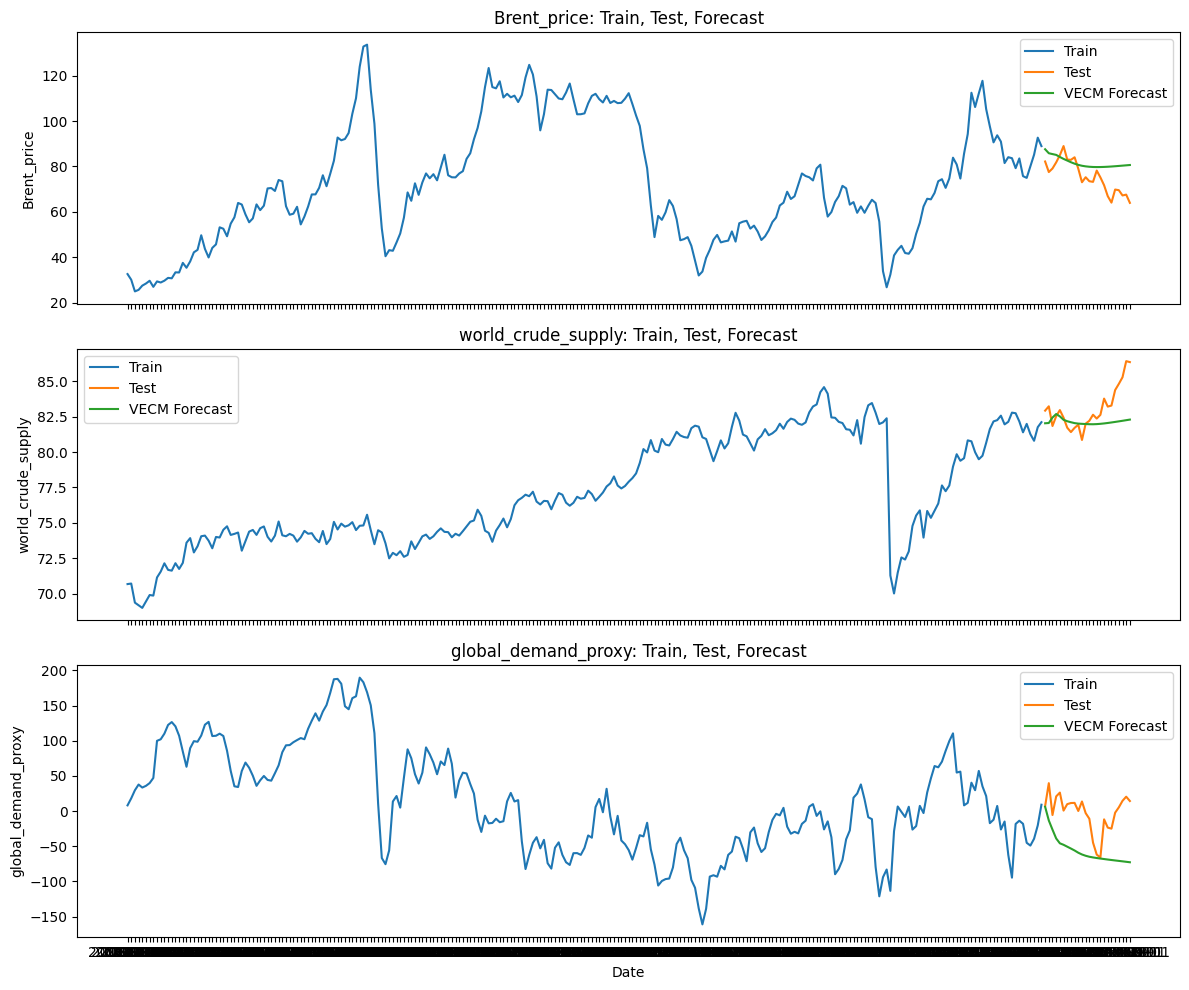

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

variables = ["Brent_price", "world_crude_supply", "global_demand_proxy"]

for i, var in enumerate(variables):

    axes[i].plot(vecm_train.index, vecm_train[var], label="Train")
    axes[i].plot(vecm_test.index, vecm_test[var], label="Test")
    axes[i].plot(vecm_forecast_df.index, vecm_forecast_df[var], label="VECM Forecast")

    axes[i].set_title(f"{var}: Train, Test, Forecast")
    axes[i].set_ylabel(var)
    axes[i].legend()

axes[-1].set_xlabel("Date")

plt.tight_layout()
plt.show()

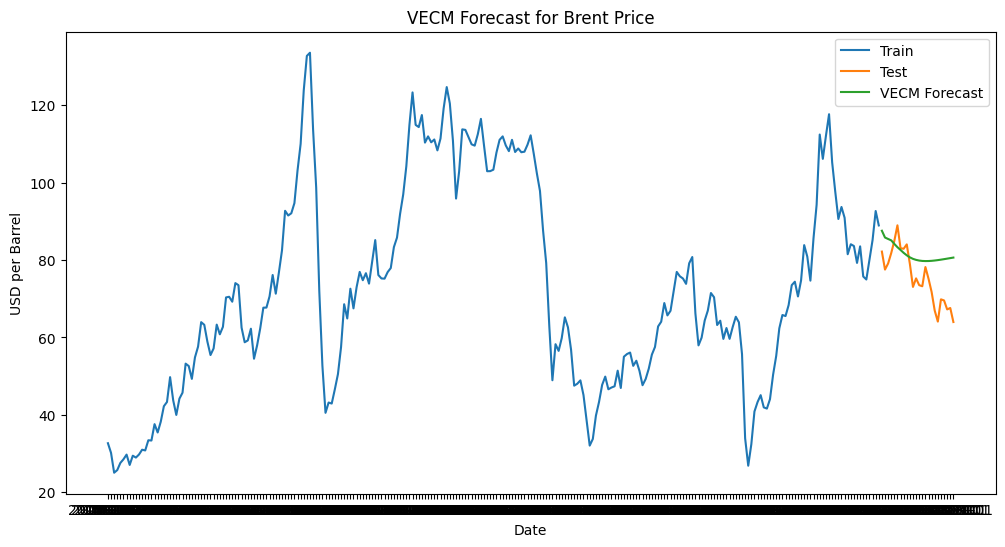

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(vecm_train.index, vecm_train["Brent_price"], label="Train")
plt.plot(vecm_test.index, vecm_test["Brent_price"], label="Test")
plt.plot(vecm_forecast_df.index, vecm_forecast_df["Brent_price"], label="VECM Forecast")

plt.title("VECM Forecast for Brent Price")
plt.xlabel("Date")
plt.ylabel("USD per Barrel")
plt.legend()

plt.show()

In [ ]:
import numpy as np

y_true = vecm_test["Brent_price"].values
y_pred = vecm_forecast_df["Brent_price"].values

mae = np.mean(np.abs(y_true - y_pred))

mse = np.mean((y_true - y_pred) ** 2)

mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

smape = 100 * np.mean(
    2 * np.abs(y_pred - y_true) /
    (np.abs(y_true) + np.abs(y_pred))
)

seasonal_lag = 12
naive_errors = vecm_train["Brent_price"].diff(seasonal_lag).dropna()
mae_naive = np.mean(np.abs(naive_errors))
mase = mae / mae_naive

print("VECM Forecast Metrics (Brent Price)")
print("-----------------------------------")
print(f"MAE:   {mae:.4f}")
print(f"MSE:   {mse:.4f}")
print(f"MAPE:  {mape:.4f}%")
print(f"sMAPE: {smape:.4f}%")
print(f"MASE:  {mase:.4f}")

VECM Forecast Metrics (Brent Price)
-----------------------------------
MAE:   6.9703
MSE:   70.6397
MAPE:  9.8239%
sMAPE: 9.1567%
MASE:  0.3444


In [ ]:
results_vecm = vecm_test[["Brent_price"]].copy()
results_vecm["Forecast_Brent"] = vecm_forecast_df["Brent_price"]

#results_vecm.to_csv("/content/drive/MyDrive/Colab Notebooks/Time series/Project/vecm_forecast.csv")

The Mean Absolute Error (MAE) of approximately 6.97 USD per barrel indicates that, on average, the model’s forecasts deviate from actual Brent prices by about seven dollars. This represents a substantial improvement compared to the VAR model, which produced significantly larger forecast errors.

The Mean Absolute Percentage Error (MAPE) of 9.82% suggests that the VECM forecasts differ from the observed prices by less than ten percent on average. In commodity price forecasting, a MAPE below 10% is generally considered reasonably accurate given the high volatility of oil markets.

The symmetric Mean Absolute Percentage Error (sMAPE) of 9.16% provides a similar measure of forecast accuracy while adjusting for scale effects, confirming that the model captures much of the price dynamics.


Overall, the VECM model performs noticeably better than the VAR model because it explicitly accounts for the cointegration relationship between the variables. By incorporating both short-run dynamics and long-run equilibrium adjustments, the VECM provides a more appropriate econometric framework for modeling the interactions between Brent oil prices, global crude oil supply, and global economic demand.